**PSE DATASET**
* Timestep: 60
* Regularization: 0.0001
* Droput: 0.5
* Units: 80

**PSEi DATASET**
* Timestep: 60
* Regularization: 0.0001
* Droput: 0.5
* Units: 80

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import os

import tensorflow as tf
import random
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Set random seeds for reproducibility
def set_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    # For GPU - if you're using one
    tf.config.experimental.enable_op_determinism()

# Call the function to set seeds
set_seeds()

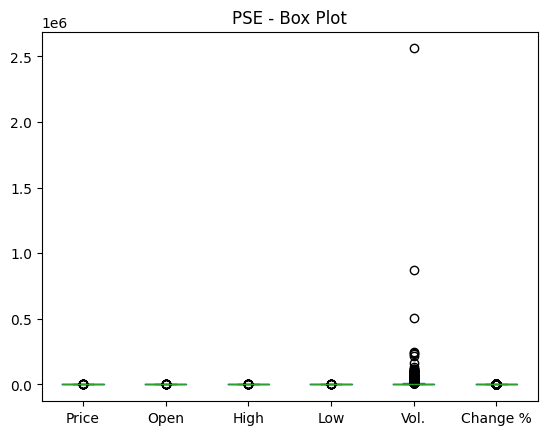

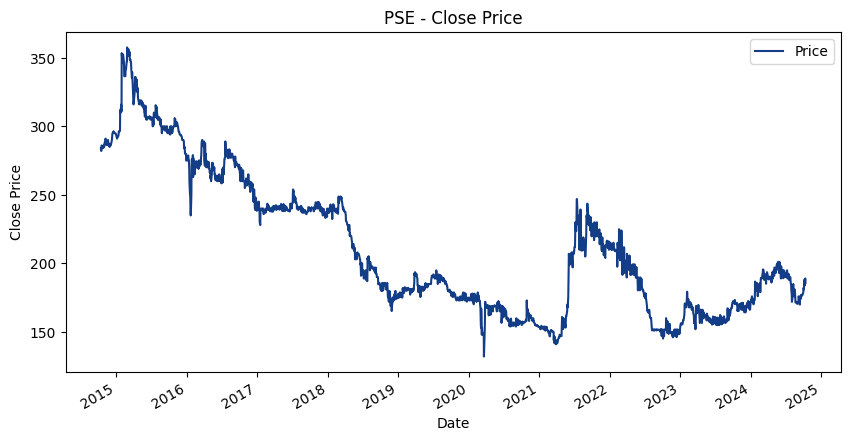

In [3]:
# Load csv
csv_filename = 'PSE.csv'  # The exact filename being read
data = pd.read_csv(csv_filename)

# Get the filename without extension for the title
filename = os.path.splitext(os.path.basename(csv_filename))[0]

# Convert and sort dates
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Function to convert suffixed numbers to numeric values
def convert_volume(volume):
    if isinstance(volume, (int, float)):
        return volume

    if 'K' in volume:
        return float(volume.replace('K', '')) * 1_000
    elif 'M' in volume:
        return float(volume.replace('M', '')) * 1_000_000
    elif 'B' in volume:
        return float(volume.replace('B', '')) * 1_000_000_000
    else:
        try:
            return float(volume)
        except ValueError:
            return np.nan

# Function to convert percentage strings to decimal numbers
def convert_percentage(change):
    if isinstance(change, float):
        return change
    elif isinstance(change, str):
        return float(change.replace('%', '')) / 100
    else:
        return np.nan

# Apply conversions
data['Vol.'] = data['Vol.'].apply(convert_volume)
data['Change %'] = data['Change %'].apply(convert_percentage)

# Original data visualization
data[['Price','Open','High','Low','Vol.', 'Change %']].plot(kind='box')
plt.title(f'{filename} - Box Plot')
plt.show()

# Time series plot of original data
data.plot(x='Date', y='Price', figsize=(10, 5), color='#133E87')
plt.title(f'{filename} - Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [4]:
# Prepare data for modeling
closing_prices = data.iloc[:, 1:2].values  # Price column
sc = MinMaxScaler(feature_range=(0,1))
scaled_prices = sc.fit_transform(closing_prices)

In [5]:
# Create sequences
timestep = 60
X, y = [], []

for i in range(timestep, len(data)):
    X.append(scaled_prices[i-timestep:i, 0])
    y.append(scaled_prices[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

regularization_factor = 0.0001

In [6]:
# Split the data into train and test sets (80-20 split)
# We'll split based on time order instead of random splitting
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
dates_train = data['Date'].iloc[timestep:train_size+timestep]
dates_test = data['Date'].iloc[train_size+timestep:]

# Build and train the model
model = Sequential([
    LSTM(units=80, return_sequences=True, input_shape=(timestep, 1),
         kernel_regularizer=l2(regularization_factor),
         recurrent_regularizer=l2(regularization_factor),
         kernel_initializer='glorot_uniform'),
    Dropout(0.5),
    LSTM(units=80, return_sequences=False,
         kernel_regularizer=l2(regularization_factor),
         recurrent_regularizer=l2(regularization_factor),
         kernel_initializer='glorot_uniform'),
    Dropout(0.5),
    Dense(units=1, kernel_regularizer=l2(regularization_factor))
])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.compile(optimizer='adam', loss="mean_squared_error")
hist = model.fit(
    X_train,
    y_train,
    epochs=50,  # Increased epochs since we have early stopping
    batch_size=64,  # Increased batch size
    validation_split=0.2,  # Added validation split
    callbacks=[early_stopping],
    verbose=2
)

# Make predictions
y_pred = model.predict(X_test)

# Inverse transform predictions and actual values
predicted_price = sc.inverse_transform(y_pred)
actual_price = sc.inverse_transform(y_test.reshape(-1, 1))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
24/24 - 13s - 537ms/step - loss: 0.0764 - val_loss: 0.0286
Epoch 2/50
24/24 - 5s - 213ms/step - loss: 0.0314 - val_loss: 0.0228
Epoch 3/50
24/24 - 1s - 27ms/step - loss: 0.0256 - val_loss: 0.0194
Epoch 4/50
24/24 - 0s - 18ms/step - loss: 0.0217 - val_loss: 0.0167
Epoch 5/50
24/24 - 1s - 32ms/step - loss: 0.0192 - val_loss: 0.0148
Epoch 6/50
24/24 - 1s - 21ms/step - loss: 0.0173 - val_loss: 0.0132
Epoch 7/50
24/24 - 1s - 25ms/step - loss: 0.0162 - val_loss: 0.0123
Epoch 8/50
24/24 - 0s - 21ms/step - loss: 0.0146 - val_loss: 0.0113
Epoch 9/50
24/24 - 1s - 21ms/step - loss: 0.0137 - val_loss: 0.0105
Epoch 10/50
24/24 - 0s - 18ms/step - loss: 0.0130 - val_loss: 0.0099
Epoch 11/50
24/24 - 1s - 25ms/step - loss: 0.0125 - val_loss: 0.0094
Epoch 12/50
24/24 - 0s - 15ms/step - loss: 0.0119 - val_loss: 0.0091
Epoch 13/50
24/24 - 0s - 16ms/step - loss: 0.0118 - val_loss: 0.0089
Epoch 14/50
24/24 - 1s - 27ms/step - loss: 0.0113 - val_loss: 0.0088
Epoch 15/50
24/24 - 0s - 13ms/step - los

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


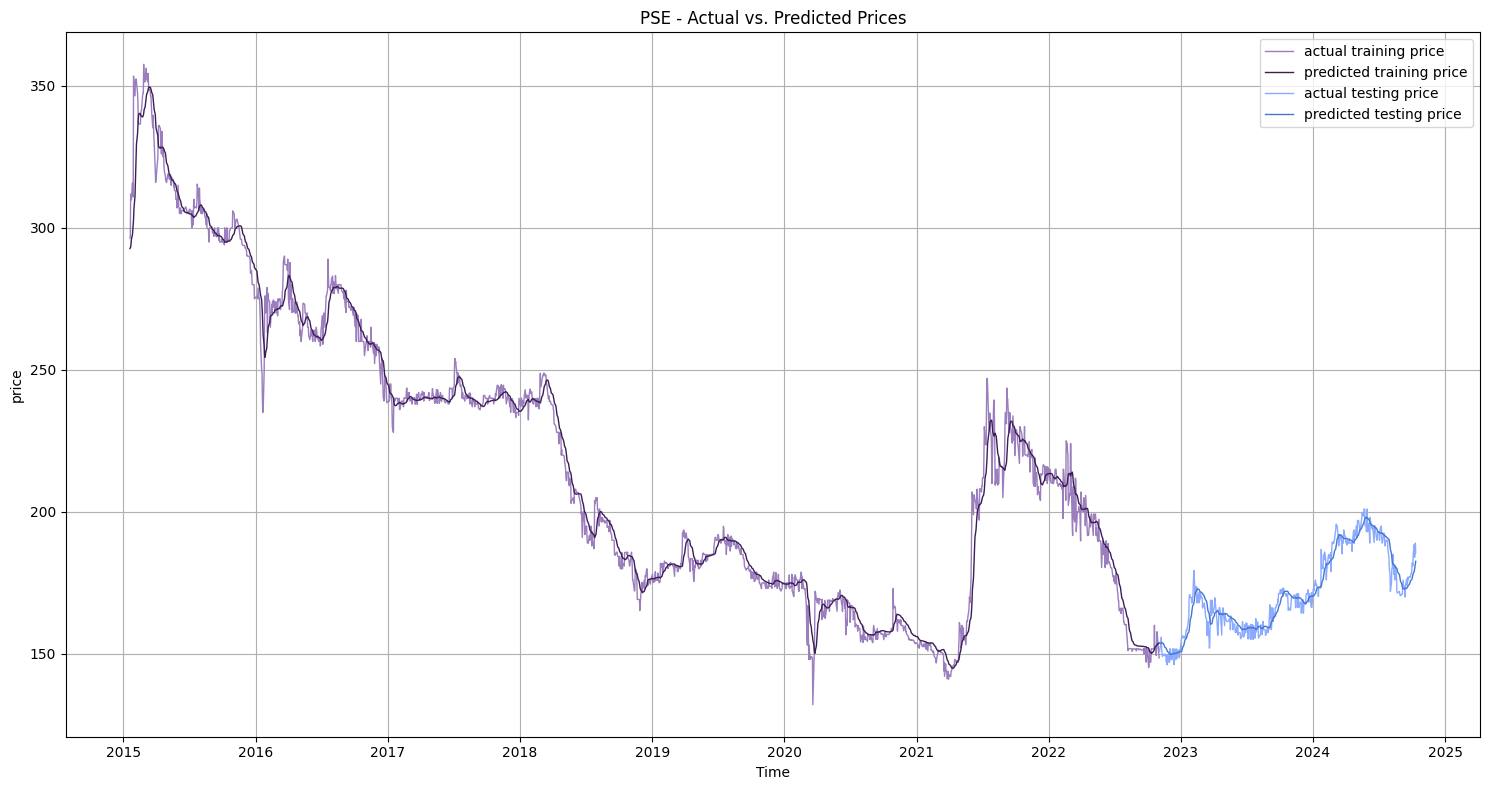

In [7]:
# Make predictions for both training and testing sets
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Inverse transform all predictions and actual values
train_pred = sc.inverse_transform(train_pred)
test_pred = sc.inverse_transform(test_pred)
train_actual = sc.inverse_transform(y_train.reshape(-1, 1))
test_actual = sc.inverse_transform(y_test.reshape(-1, 1))

# Create the visualization for actual vs predicted
plt.figure(figsize=(15, 8))
plt.grid(True)

# Plot training data
plt.plot(dates_train, train_actual, '#9B7EBD', label='actual training price', linewidth=1)
plt.plot(dates_train, train_pred, '#3B1E54', label='predicted training price', linewidth=1)

# Plot testing data
plt.plot(dates_test, test_actual, '#8CABFF', label='actual testing price', linewidth=1)
plt.plot(dates_test, test_pred, '#4477CE', label='predicted testing price', linewidth=1)

plt.title(f'{filename} - Actual vs. Predicted Prices')
plt.xlabel('Time')
plt.ylabel('price')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate performance
mse = mean_squared_error(test_actual, test_pred)
mae = mean_absolute_error(test_actual, test_pred)
rmse = np.sqrt(mse)
r_squared = r2_score(test_actual, test_pred)

print("\nTest Set Performance Metrics:")
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared: {r_squared:.4f}')

# Calculate training set metrics
train_mse = mean_squared_error(train_actual, train_pred)
train_mae = mean_absolute_error(train_actual, train_pred)
train_rmse = np.sqrt(train_mse)
train_r_squared = r2_score(train_actual, train_pred)

print("\nTraining Set Performance Metrics:")
print(f'Mean Squared Error (MSE): {train_mse:.2f}')
print(f'Mean Absolute Error (MAE): {train_mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {train_rmse:.2f}')
print(f'R-squared: {train_r_squared:.4f}')

In [10]:
print("\nTest Set Performance Metrics:")
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared: {r_squared:.4f}')


print("\nTraining Set Performance Metrics:")
print(f'Mean Squared Error (MSE): {train_mse:.2f}')
print(f'Mean Absolute Error (MAE): {train_mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {train_rmse:.2f}')
print(f'R-squared: {train_r_squared:.4f}')


Test Set Performance Metrics:
Mean Squared Error (MSE): 14.41
Mean Absolute Error (MAE): 2.98
Root Mean Squared Error (RMSE): 3.80
R-squared: 0.9267

Training Set Performance Metrics:
Mean Squared Error (MSE): 36.48
Mean Absolute Error (MAE): 3.84
Root Mean Squared Error (RMSE): 6.04
R-squared: 0.9861


In [8]:
# Future predictions
last_date = data['Date'].iloc[-1]
last_60_days = scaled_prices[- + timestep:]

future_predictions = []
future_dates = []

# Predict next 7 working days
num_days_to_predict = 14

for i in range(num_days_to_predict):
    # Reshape last 60 days for model input
    X_future = np.array([last_60_days])
    X_future = np.reshape(X_future, (1, timestep, 1))

    # Make prediction
    next_pred = model.predict(X_future)

    # Append prediction and update sequence
    future_predictions.append(next_pred[0,0])
    last_60_days = np.append(last_60_days[1:], next_pred[0,0])

    # Advance the date, skipping weekends
    last_date += pd.Timedelta(days=1)
    while last_date.weekday() >= 5:
        last_date += pd.Timedelta(days=1)
    future_dates.append(last_date)

# Convert predictions back to original scale
future_predictions = sc.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create DataFrame with predictions
future_predictions_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Price': future_predictions.flatten()
})
print("\nFuture Predictions:")
print(future_predictions_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Future Predictions:
         Date  Predicted_Price
0  2024-10-14       183.356796
1  2024-10-15       183.854431
2  2024-10-16       184.184601
3  2024-10-17       184.407242
4  2024-10-18       184.561203
5  2024-10-21       184.671539
6  2024-10-22       184.754272
7  2024-10-23       184.819672
8  2024-10-24       184.874191
9  2024-10-25       184.921906
10 2024-10-28       184.965393
11 2024-10-29       185.006226
12 2024-10-30       185.045364
13 2024-10-31

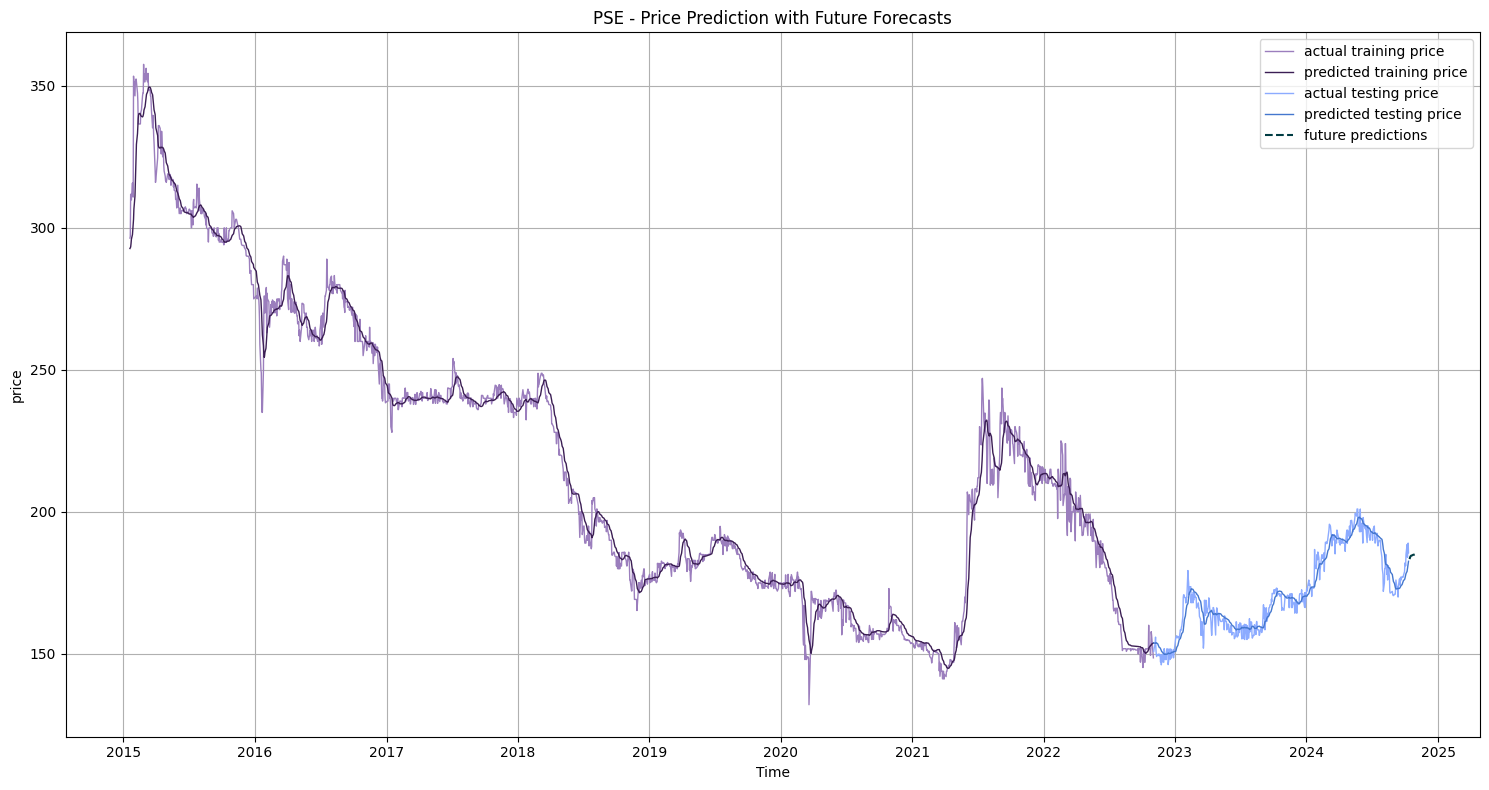

In [9]:
# Final plot with future predictions
plt.figure(figsize=(15, 8))
plt.grid(True)

# Plot training data
plt.plot(dates_train, train_actual, '#9B7EBD', label='actual training price', linewidth=1)
plt.plot(dates_train, train_pred, '#3B1E54', label='predicted training price', linewidth=1)

# Plot testing data
plt.plot(dates_test, test_actual, '#8CABFF', label='actual testing price', linewidth=1)
plt.plot(dates_test, test_pred, '#4477CE', label='predicted testing price', linewidth=1)

# Plot future predictions
plt.plot(future_predictions_df['Date'], future_predictions_df['Predicted_Price'],
         color='#003C43', linestyle='dashed', label='future predictions')

plt.title(f'{filename} - Price Prediction with Future Forecasts')
plt.xlabel('Time')
plt.ylabel('price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()